In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fontTools.diff import color

In [2]:
heart = pd.read_csv('DataSet/heart.csv')
heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
attr_desc = {
    'age'     : 'Age in years',
    'sex'     : '1 = male, 0 = female',
    'cp'      : 'Chest pain type',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol'    : 'Serum cholesterol (mg/dl)',
    'fbs'     : 'Fasting blood sugar > 120 mg/dl (1=True)',
    'restecg' : 'Resting ECG results',
    'thalach' : 'Maximum heart rate achieved',
    'exang'   : 'Exercise-induced angina (1=Yes)',
    'oldpeak' : 'ST depression induced by exercise',
    'slope'   : 'Slope of peak exercise ST segment',
    'ca'      : '# major vessels coloured by fluoroscopy',
    'thal'    : 'Thalassemia',
    'target'  : '1 = disease, 0 = no disease'
}
print("Attribute Descriptions:")
for k, v in attr_desc.items():
    print(f"  {k:<8}: {v}")

Attribute Descriptions:
  age     : Age in years
  sex     : 1 = male, 0 = female
  cp      : Chest pain type
  trestbps: Resting blood pressure (mm Hg)
  chol    : Serum cholesterol (mg/dl)
  fbs     : Fasting blood sugar > 120 mg/dl (1=True)
  restecg : Resting ECG results
  thalach : Maximum heart rate achieved
  exang   : Exercise-induced angina (1=Yes)
  oldpeak : ST depression induced by exercise
  slope   : Slope of peak exercise ST segment
  ca      : # major vessels coloured by fluoroscopy
  thal    : Thalassemia
  target  : 1 = disease, 0 = no disease


Basic Statistics of the dataset

In [4]:
heart.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


Check if missing values

In [5]:
heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
nulls = heart.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values found!")

No missing values found!


Step1: understand dataset attributes

Define column categories

In [7]:
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
target_col = "target"

Check duplicates

In [8]:
heart[heart.duplicated(keep=False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [9]:
heart.drop_duplicates(inplace=True)
heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


Detect outliers

In [10]:
def outliers_iqr(dataframe, columns):
    print("Outlier Summary (IQR Method): ")
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = dataframe[
            (dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)
        ]
        print(f"   {col:<9}: {len(outliers)} outliers")


outliers_iqr(heart, numerical_cols)

Outlier Summary (IQR Method): 
   age      : 0 outliers
   trestbps : 9 outliers
   chol     : 5 outliers
   thalach  : 1 outliers
   oldpeak  : 5 outliers


Boxplot 

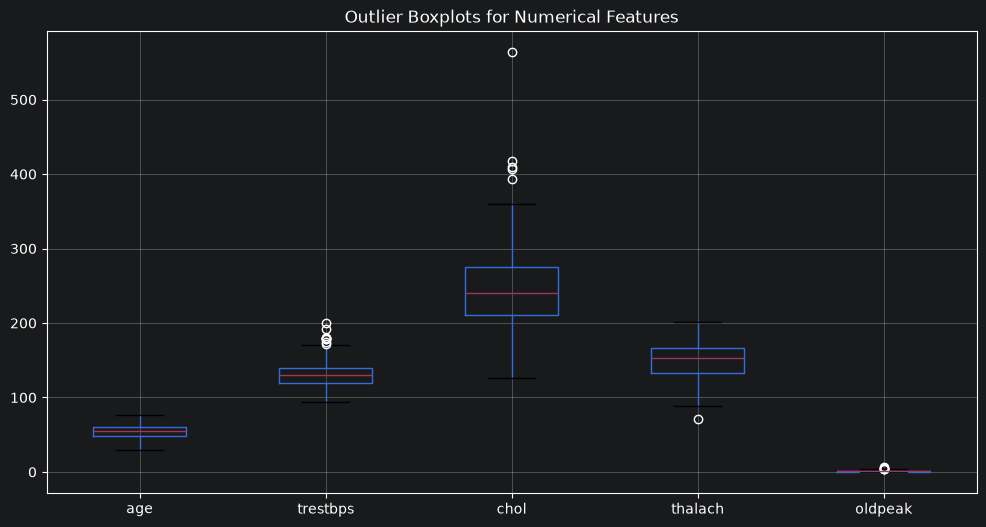

In [11]:
plt.figure(figsize=(12, 6))
heart[numerical_cols].boxplot()
plt.title("Outlier Boxplots for Numerical Features")
plt.show()

correlation relations between variables

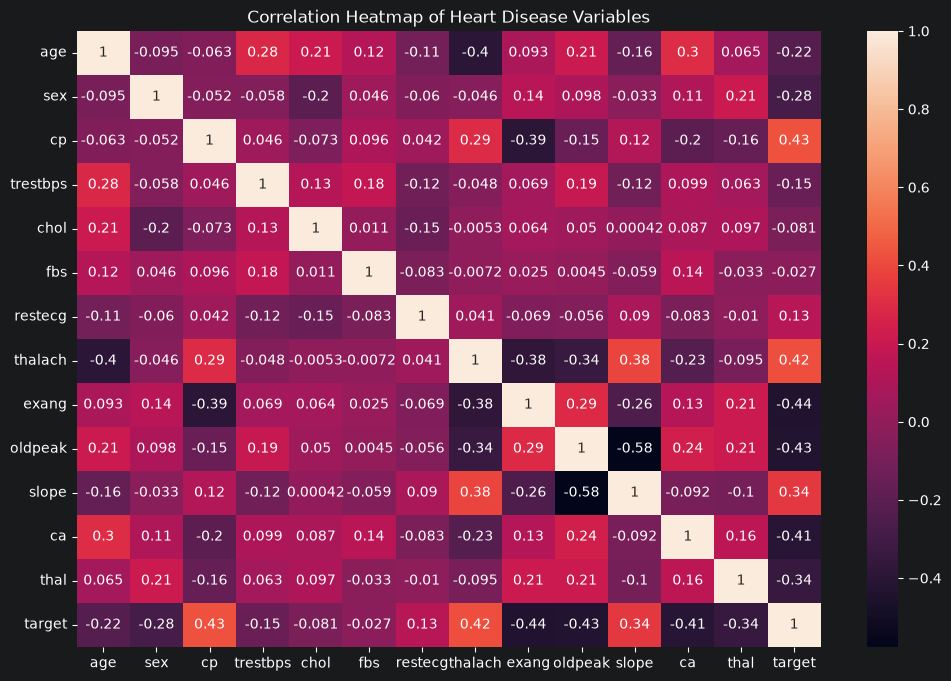

In [12]:
corr_matrix = heart.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap of Heart Disease Variables")
plt.show()

Correlation coefficient between each feature and target

In [13]:
print("Correlation with Target Variable:")
print(corr_matrix["target"].sort_values(ascending=False), "\n")
print("correlation coff. (]0, 1] -> Direct relation), ([-1, 0[ -> Inverse relation), (0 -> No relation)")

Correlation with Target Variable:
target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64 

correlation coff. (]0, 1] -> Direct relation), ([-1, 0[ -> Inverse relation), (0 -> No relation)


Gender based analysis

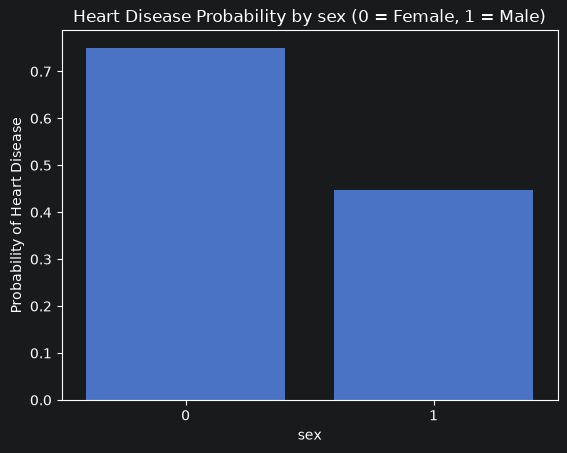

Percentage of Females with heart disease: 75.00%
Percentage of Males with heart disease: 44.66%


In [14]:
sns.barplot(x='sex', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by sex (0 = Female, 1 = Male)")
plt.ylabel("Probability of Heart Disease")
plt.show()

# Calculate exact percentages
rates = heart.groupby('sex')['target'].mean() * 100
print(f"Percentage of Females with heart disease: {rates[0]:.2f}%")
print(f"Percentage of Males with heart disease: {rates[1]:.2f}%")

Age based analysis

Descretization 

In [15]:
bins = [0, 40, 55, 100]
labels = ['Young (<40)', 'Middle-Aged (40-55)', 'Senior (55+)']
heart['age_group'] = pd.cut(heart['age'], bins=bins, labels=labels)

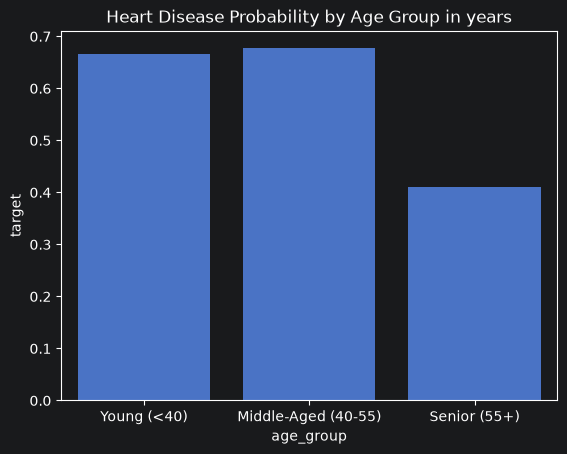


Percentage of diagnosed people by age group with heart disease:
age_group
Young (<40)            66.666667
Middle-Aged (40-55)    67.669173
Senior (55+)           41.059603
Name: target, dtype: float64


In [16]:
sns.barplot(x='age_group', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by Age Group in years")
plt.show()

# Calculate exact percentages
rates = heart.groupby('age_group')['target'].mean() * 100
print("\nPercentage of diagnosed people by age group with heart disease:")
print(rates)

Chest pain based analysis

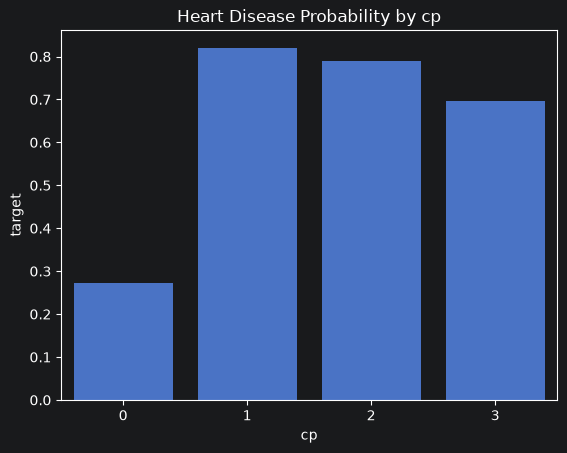

Percentage of chest pain type 0 with heart disease: 27.27%
Percentage of chest pain type 1 with heart disease: 82.00%
Percentage of chest pain type 2 with heart disease: 79.07%
Percentage of chest pain type 3 with heart disease: 69.57%


In [17]:
sns.barplot(x='cp', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by cp")
plt.show()

# Calculate exact percentages
rates = heart.groupby('cp')['target'].mean() * 100
for i in [0,1,2,3]:
    print(f"Percentage of chest pain type {i} with heart disease: {rates[i]:.2f}%")

In [18]:
bins = [90, 110, 160, 200]
labels = ['low (<110)', 'Normal (110-160)', 'high (160+)']
heart['trestbps_group'] = pd.cut(heart['trestbps'], bins=bins, labels=labels)

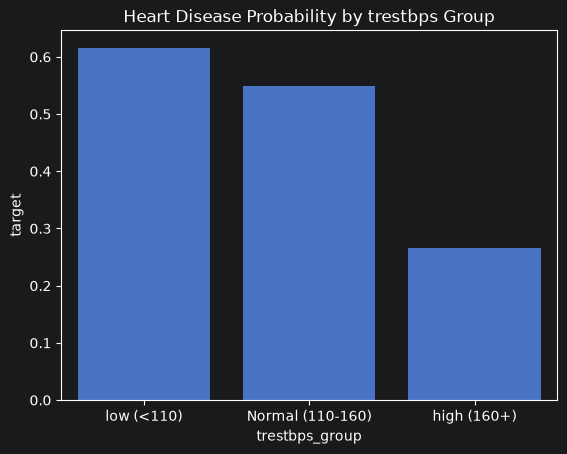


Percentage of diagnosed people by trestbps group with heart disease:
trestbps_group
low (<110)          61.538462
Normal (110-160)    54.838710
high (160+)         26.666667
Name: target, dtype: float64


In [19]:
sns.barplot(x='trestbps_group', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by trestbps Group")
plt.show()

# Calculate exact percentages
rates = heart.groupby('trestbps_group')['target'].mean() * 100
print("\nPercentage of diagnosed people by trestbps group with heart disease:")
print(rates)

In [20]:
bins = [125, 250, 400, 550]
labels = ['(125 - 250)', '(250-400)', 'high (400 - 550)']
heart['chol_group'] = pd.cut(heart['chol'], bins=bins, labels=labels)

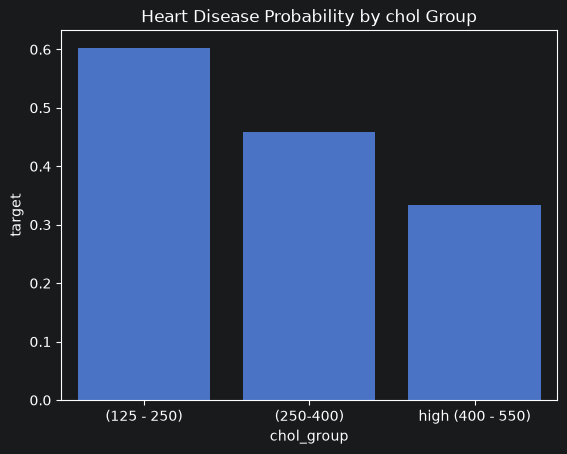


Percentage of chol Group with heart disease:
chol_group
(125 - 250)         60.227273
(250-400)           45.901639
high (400 - 550)    33.333333
Name: target, dtype: float64


In [21]:
sns.barplot(x='chol_group', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by chol Group")
plt.show()

# Calculate exact percentages
rates = heart.groupby('chol_group')['target'].mean() * 100
print("\nPercentage of chol Group with heart disease:")
print(rates)

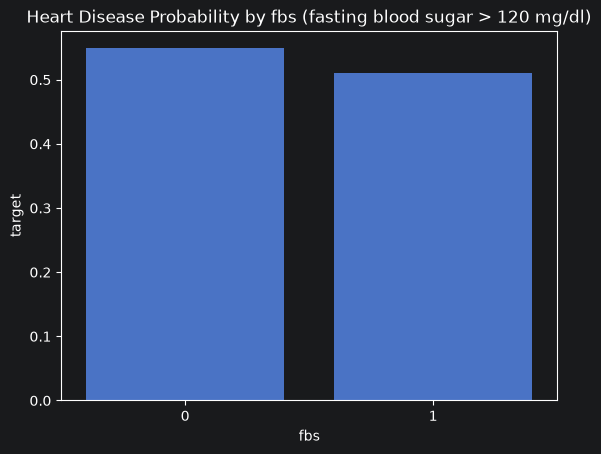

Percentage of < 120 mg/dl with heart disease: 54.86%
Percentage of > 120 mg/dl with heart disease: 51.11%


In [22]:
sns.barplot(x='fbs', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by fbs (fasting blood sugar > 120 mg/dl)")
plt.show()

# Calculate exact percentages
rates = heart.groupby('fbs')['target'].mean() * 100
print(f"Percentage of < 120 mg/dl with heart disease: {rates[0]:.2f}%")
print(f"Percentage of > 120 mg/dl with heart disease: {rates[1]:.2f}%")

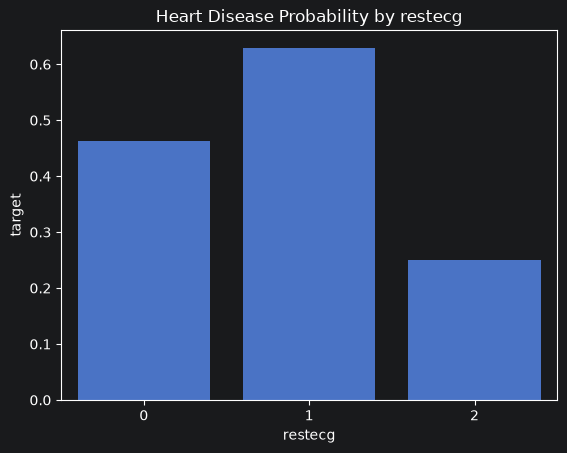

Percentage of Resting ECG type 0 with heart disease: 46.26%
Percentage of Resting ECG type 1 with heart disease: 62.91%
Percentage of Resting ECG type 2 with heart disease: 25.00%


In [23]:
sns.barplot(x='restecg', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by restecg")
plt.show()

# Calculate exact percentages
rates = heart.groupby('restecg')['target'].mean() * 100
for i in [0,1,2]:
    print(f"Percentage of Resting ECG type {i} with heart disease: {rates[i]:.2f}%")

In [24]:
bins = [70, 110, 160, 210]
labels = ['(70 - 110)', '(110-160)', '(160 - 210)']
heart['thalach_group'] = pd.cut(heart['thalach'], bins=bins, labels=labels)

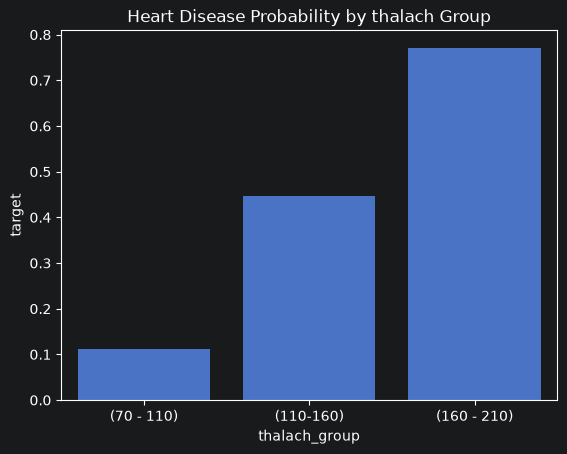


Percentage of diagnosed people by thalach group with heart disease:
thalach_group
(70 - 110)     11.111111
(110-160)      44.571429
(160 - 210)    77.064220
Name: target, dtype: float64


In [25]:
sns.barplot(x='thalach_group', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by thalach Group")
plt.show()

# Calculate exact percentages
rates = heart.groupby('thalach_group')['target'].mean() * 100
print("\nPercentage of diagnosed people by thalach group with heart disease:")
print(rates)

In [26]:
bins = [0, 2, 4, 7]
labels = ['(0 - 2)', '(2-4)', '(4 - 7)']
heart['oldpeak_group'] = pd.cut(heart['oldpeak'], bins=bins, labels=labels)

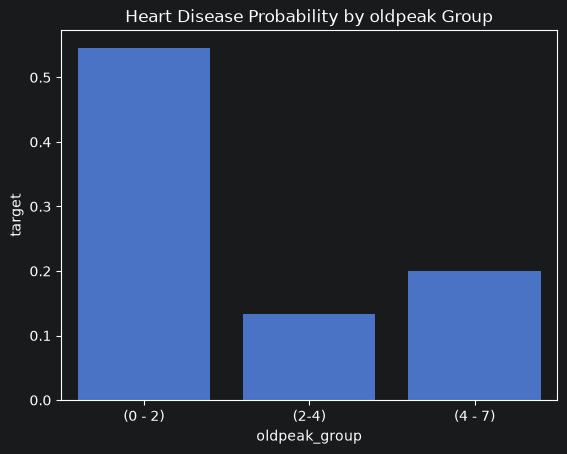


Percentage of oldpeak with heart disease:
oldpeak_group
(0 - 2)    54.545455
(2-4)      13.333333
(4 - 7)    20.000000
Name: target, dtype: float64


In [27]:
sns.barplot(x='oldpeak_group', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by oldpeak Group")
plt.show()

# Calculate exact percentages
rates = heart.groupby('oldpeak_group')['target'].mean() * 100
print("\nPercentage of oldpeak with heart disease:")
print(rates)

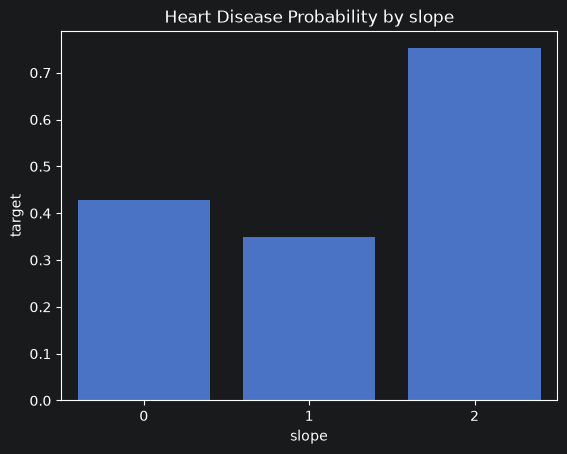

Percentage of Slope of peak exercise ST segment 0 with heart disease: 42.86%
Percentage of Slope of peak exercise ST segment 1 with heart disease: 35.00%
Percentage of Slope of peak exercise ST segment 2 with heart disease: 75.18%


In [28]:
sns.barplot(x='slope', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by slope")
plt.show()

# Calculate exact percentages
rates = heart.groupby('slope')['target'].mean() * 100
for i in [0,1,2]:
    print(f"Percentage of Slope of peak exercise ST segment {i} with heart disease: {rates[i]:.2f}%")

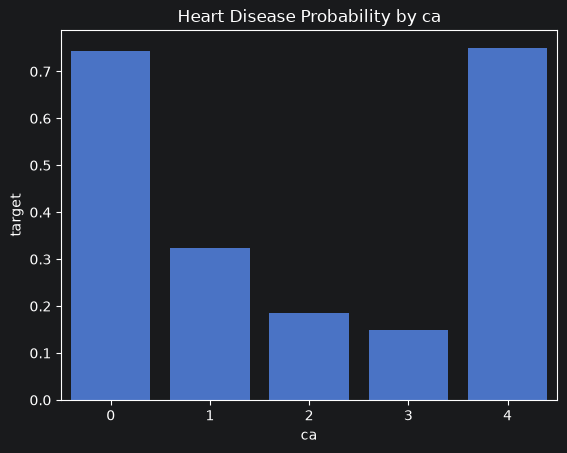

Percentage of ca type 0 with heart disease: 74.29%
Percentage of ca type 1 with heart disease: 32.31%
Percentage of ca type 2 with heart disease: 18.42%
Percentage of ca type 3 with heart disease: 15.00%


In [29]:
sns.barplot(x='ca', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by ca")
plt.show()

# Calculate exact percentages
rates = heart.groupby('ca')['target'].mean() * 100
for i in [0,1,2,3]:
    print(f"Percentage of ca type {i} with heart disease: {rates[i]:.2f}%")

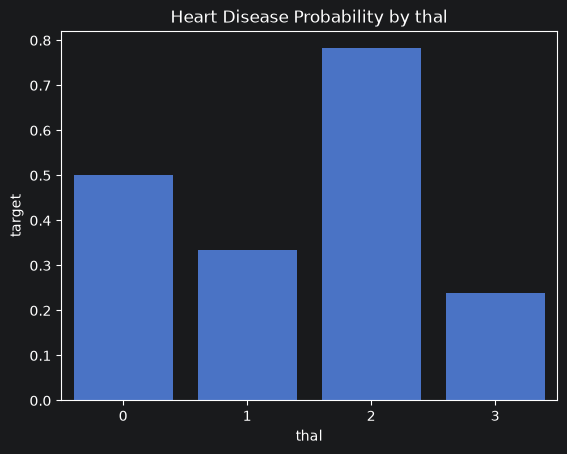

Percentage of thal type: 0 with heart disease: 50.00%
Percentage of thal type: 1 with heart disease: 33.33%
Percentage of thal type: 2 with heart disease: 78.18%


In [30]:
sns.barplot(x='thal', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by thal")
plt.show()

# Calculate exact percentages
rates = heart.groupby('thal')['target'].mean() * 100
for i in [0,1,2]:
    print(f"Percentage of thal type: {i} with heart disease: {rates[i]:.2f}%")